<a href="https://colab.research.google.com/github/ABDULRAHEEM77/Machine-Learning-project/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 4.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
dataset = [11,10,12,14,12,15,14,13,15,102,12,14,17,19,107,10,13,12,14,12,108,12,11,14,13,15,10,15,12,10,14,13,15,10]

In [ ]:
df = pd.read_csv("Mall_Customers_missing (1).csv")
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19.0,15.0,39.0
1,2,Male,NaN,NaN,81.0
2,3,NaN,20.0,16.0,NaN
3,4,Female,23.0,16.0,77.0
4,5,NaN,31.0,17.0,40.0


In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
row, col = df.shape
row

In [ ]:
(df.isnull().sum()/row) * 100

In [ ]:
df_num_ft = df.select_dtypes(include=["int64", "float64"])
df_num_ft

In [ ]:
df_cat_ft = df.select_dtypes(include=["object", "category"])
df_cat_ft

In [ ]:
df_drop_row = df.dropna()
df_drop_row

In [ ]:
df_cat_filled = df_cat_ft.fillna("Missing")
df_cat_filled

In [ ]:
df_cat_ft.iloc[0]

In [ ]:
df_cat_filled = df_cat_ft.fillna(df_cat_ft.mode().iloc[0])
df_cat_filled

In [ ]:
df_cat_filled.isnull().sum()

In [ ]:
df_num_fill = df_num_ft.fillna(df_num_ft.mean())
df_num_fill

In [ ]:
df_num_fill = df_num_ft.fillna(df_num_ft.median())
df_num_fill

In [ ]:
df_num_fill = df_num_ft.fillna(df_num_ft.mode())
df_num_fill

## forward fill backward fill

In [ ]:
df_fill = df.fillna(method="ffill")
df_fill

In [ ]:
df = pd.read_csv("Advertising (1).csv")

In [ ]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [ ]:
# Do the preprocessing
# Find the missing values
# Outliers
df.isnull().sum()

,0
TV,0
radio,0
newspaper,0
sales,0


In [ ]:
df.mean()

,0
TV,147.0425
radio,23.2640
newspaper,30.5540
sales,14.0225


In [ ]:
df.median()

,0
TV,149.75
radio,22.90
newspaper,25.75
sales,12.90


<Axes: >

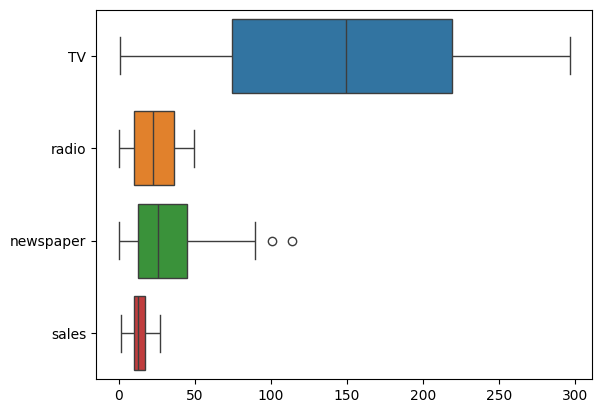

In [ ]:
sns.boxplot(data=df, orient= 'h')

<Axes: xlabel='None'>

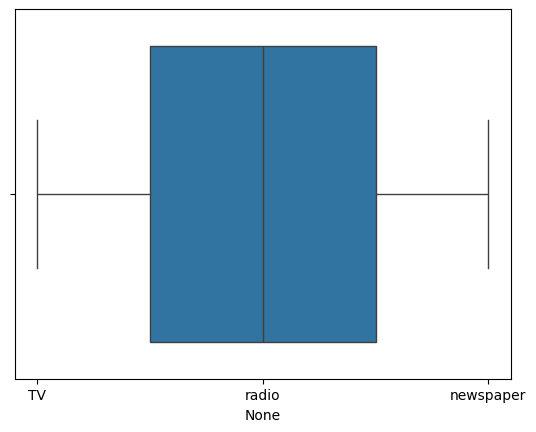

In [ ]:
sns.boxplot(x=df.columns[:3])

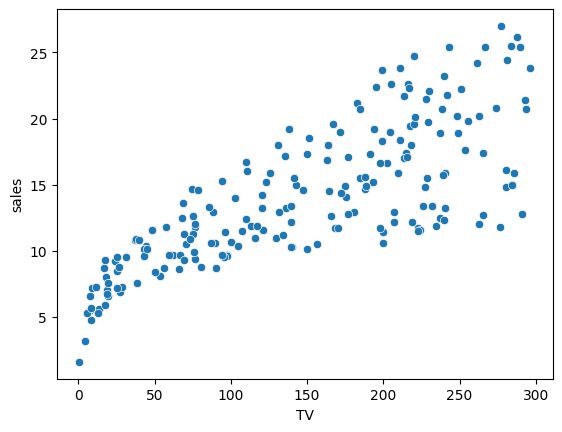

In [ ]:
sns.scatterplot(x=df['TV'], y=df['sales']);

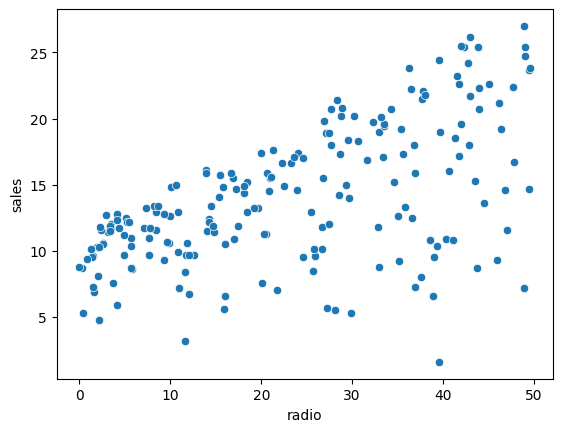

In [ ]:
sns.scatterplot(x=df['radio'], y=df['sales']);

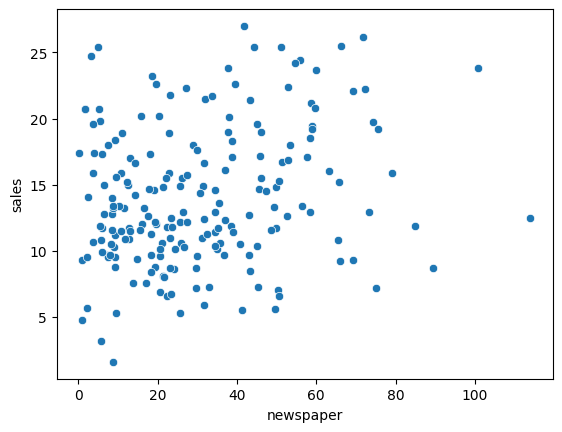

In [ ]:
sns.scatterplot(x=df['newspaper'], y=df['sales']);

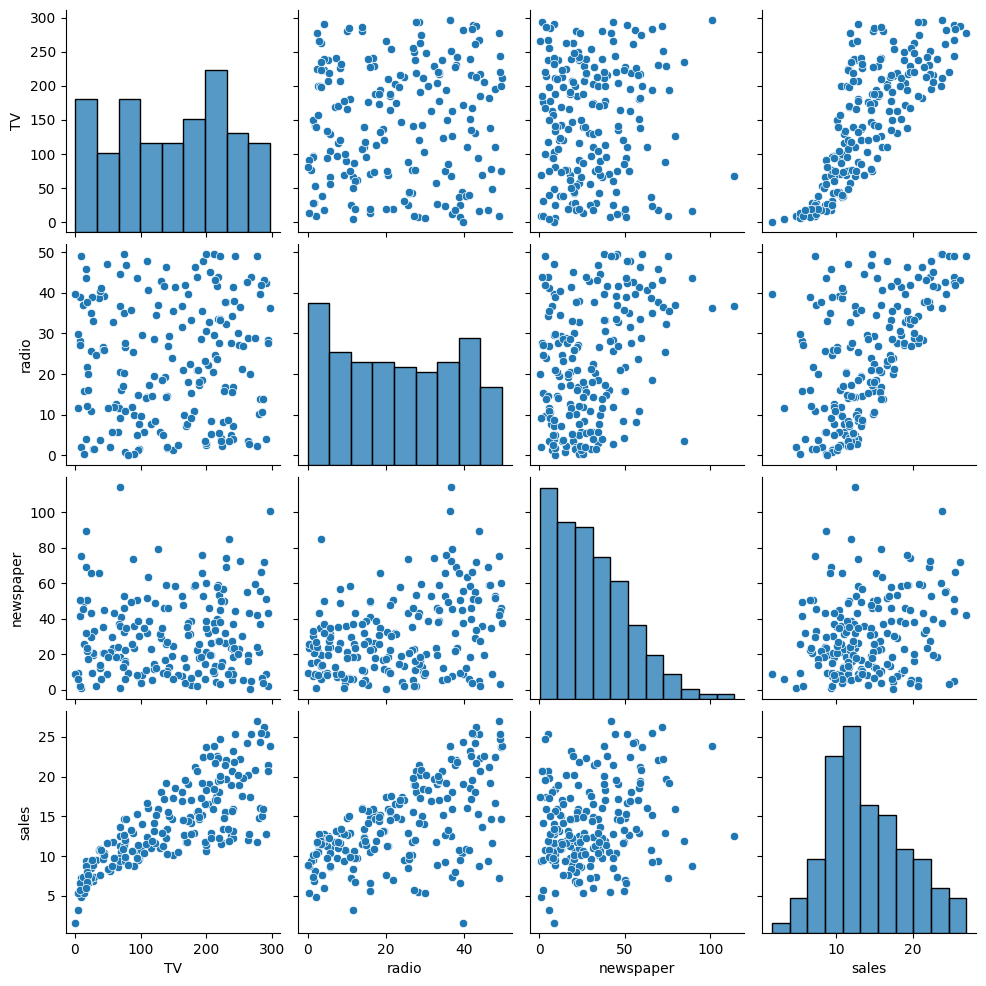

In [ ]:
sns.pairplot(df);

<Axes: >

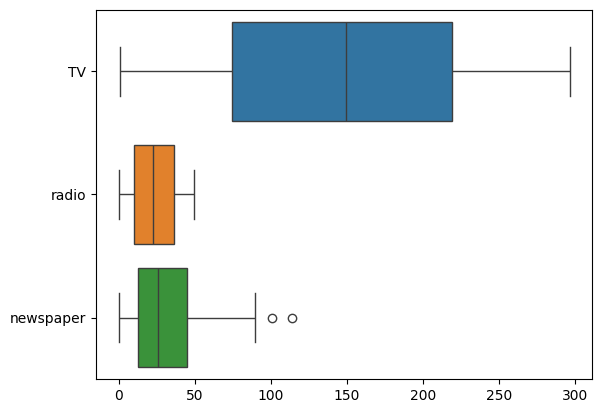

In [ ]:
# IQR
sns.boxplot(data=df[["TV", "radio", "newspaper"]], orient= 'h')

In [ ]:
# splitting the data into X and y
X = df.drop('sales', axis=1)
y = df['sales']

In [ ]:
X.shape

(200, 3)

In [ ]:
# Divide the dataset to train and test the model
from sklearn.model_selection import train_test_split

In [ ]:
# Test dataset is also known as unseen dataset

**Feature scaling**

In [ ]:
# standard Scaler
# Minmax scaler
# Robust IQR scaler
from sklearn.preprocessing import StandardScaler

In [ ]:
Scaler = StandardScaler()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train_scaled = Scaler.fit_transform(X_train)

In [ ]:
# prompt: X_test_scaled = Scaler.transform(X_test), How I defined X_train_scaled

X_test_scaled = Scaler.transform(X_test)


In [ ]:
X_test_scaled = Scaler.transform(X_test)

**Import Model**

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)
y_pred

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967,
        9.04831992,  6.65328312, 14.34554487,  8.90349333,  9.68959028,
       12.16494386,  8.73628397, 16.26507258, 10.27759582, 18.83109103,
       19.56036653, 13.25103464, 12.33620695, 21.30695132,  7.82740305,
        5.80957448, 20.75753231, 11.98138077,  9.18349576,  8.5066991 ,
       12.46646769, 10.00337695, 21.3876709 , 12.24966368, 18.26661538,
       20.13766267, 14.05514005, 20.85411186, 11.0174441 ,  4.56899622])

In [ ]:
y_test

,sales
95,16.9
15,22.4
30,21.4
158,7.3
128,24.7
115,12.6
69,22.3
170,8.4
174,11.5
45,14.9


## Evaluating a Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 1.4607567168117606


In [ ]:
# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error: {rmse}")

Root Mean Square Error: 1.7815996615334506


In [ ]:
# R2
r_sq = r2_score(y_test, y_pred)
print(f"R2 Score: {r_sq}")

R2 Score: 0.8994380241009119


In [ ]:
# R2 second Method
r2 = model.score(X_test_scaled, y_test)
print(f"R2 Score: {r2:}%")

R2 Score: 0.8994380241009119%


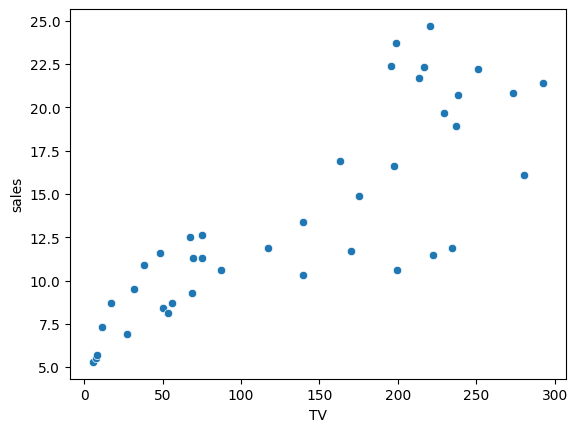

In [ ]:
sns.scatterplot(x=X_test['TV'], y=y_test);

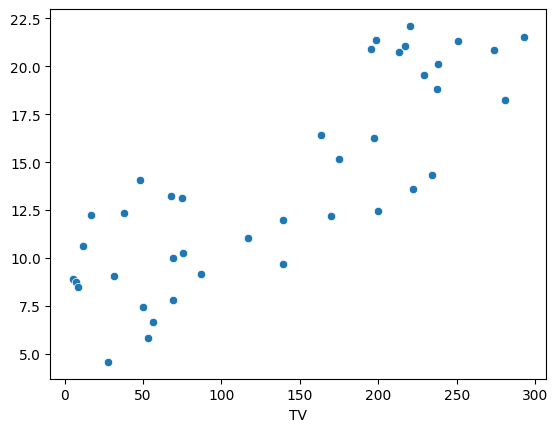

In [ ]:
sns.scatterplot(x=X_test['TV'], y=y_pred);

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
## Task is to import social anxiety dataset
## From GCR and apply all the mentioned step
## Linear Regression
## share your model's evaluation (MAE, RMSE, R2) on meet chat
df = pd.read_csv("social_anxiety_dataset.csv")
df.head()



,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


In [ ]:
df1.shape

In [ ]:
# prompt: # prompt to generate R2 score

# R2 score is already calculated and printed in the provided code.
# Here's the relevant section again for clarity:

# R2
r_sq = r2_score(y_test, y_pred)
print(f"R2 Score: {r_sq}")

# R2 second Method
r2 = model.score(X_test_scaled, y_test)
print(f"R2 Score: {r2:}%")



R2 Score: 0.8994380241009119
R2 Score: 0.8994380241009119%


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
Scaler = StandardScaler()

In [ ]:
X_train_scaled = Scaler.fit_transform(X_train)

In [ ]:
X_test_scaled = Scaler.transform(X_test)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)
y_pred


array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967,
        9.04831992,  6.65328312, 14.34554487,  8.90349333,  9.68959028,
       12.16494386,  8.73628397, 16.26507258, 10.27759582, 18.83109103,
       19.56036653, 13.25103464, 12.33620695, 21.30695132,  7.82740305,
        5.80957448, 20.75753231, 11.98138077,  9.18349576,  8.5066991 ,
       12.46646769, 10.00337695, 21.3876709 , 12.24966368, 18.26661538,
       20.13766267, 14.05514005, 20.85411186, 11.0174441 ,  4.56899622])

In [ ]:
y_test

,sales
95,16.9
15,22.4
30,21.4
158,7.3
128,24.7
115,12.6
69,22.3
170,8.4
174,11.5
45,14.9


In [ ]:
# mae
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 1.4607567168117606


In [ ]:
# Rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error: {rmse}")

Root Mean Square Error: 1.7815996615334506


In [ ]:
# R2
r_sq = r2_score(y_test, y_pred)
print(f"R2 Score: {r_sq}")

R2 Score: 0.8994380241009119


## Logistic Regression

In [ ]:
df = pd.read_csv("hearing_test.csv")
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [ ]:
df.shape


(5000, 3)

In [ ]:
df.isnull().sum()

,0
age,0
physical_score,0
test_result,0


<Axes: >

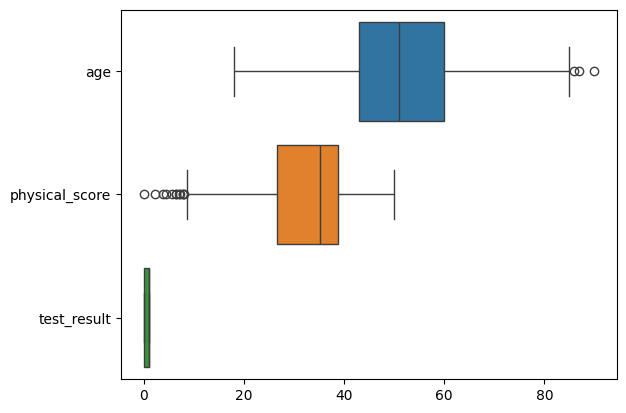

In [ ]:
sns.boxplot(data=df, orient= 'h')

In [ ]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [ ]:
X = df.drop('test_result', axis=1)
y = df['test_result']

In [ ]:
df['test_result'].value_counts()

,count
test_result,
1,3000
0,2000


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = Scaler.fit_transform(X_train)

In [ ]:
X_test_scaled = Scaler.transform(X_test)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,

In [ ]:
y_test

,test_result
1501,0
2586,0
2653,1
1055,1
705,0
...,...
4711,1
2313,1
3214,1
2732,1


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 89.70%


In [ ]:
def report(model):
  acc = accuracy_score(y_test, y_pred)
  error = 1-acc
  print(f"Accuracy Score: {acc*100:.2f}%")
  print(f"Error: {error*100:.2f}%")

  conf_mat = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(conf_mat, display_labels=model.classes_)
  disp.plot()
  plt.grid(False)
  disp.ax_.set_title("Confusion Matrix")
  plt.grid(False)

Accuracy Score: 89.70%
Error: 10.30%


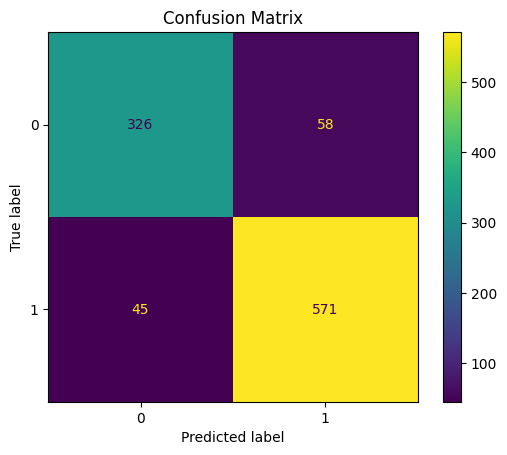

In [ ]:
report(model)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv("social_anxiety_dataset.csv")
df.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


In [ ]:
df_cat_feats = df.select_dtypes(include=["object", "category"])
df_cat_feats

,Gender,Occupation,Smoking,Family History of Anxiety,Dizziness,Medication,Recent Major Life Event
0,Female,Artist,Yes,No,No,Yes,Yes
1,Other,Nurse,Yes,Yes,Yes,No,No
2,Male,Other,No,Yes,No,No,Yes
3,Female,Scientist,Yes,No,No,No,No
4,Female,Other,Yes,No,Yes,Yes,No
...,...,...,...,...,...,...,...
10995,Female,Engineer,Yes,No,Yes,Yes,No
10996,Other,Teacher,Yes,No,No,No,No
10997,Male,Nurse,No,No,Yes,Yes,Yes
10998,Other,Artist,No,No,Yes,Yes,Yes


In [ ]:
df_num_feats = df.select_dtypes(include=["int64", "float64"])

# 1. Label Encoding

In [ ]:

from sklearn.preprocessing import LabelEncoder

In [ ]:
df_cat_feats.columns

Index(['Gender', 'Occupation', 'Smoking', 'Family History of Anxiety',
       'Dizziness', 'Medication', 'Recent Major Life Event'],
      dtype='object')

In [ ]:
len(df_cat_feats.columns)

7

In [ ]:
label_encoder = LabelEncoder()

In [ ]:
df_cat_copy = df_cat_feats.copy()

In [ ]:
for i in df_cat_feats.columns:
  df_cat_copy[i] = label_encoder.fit_transform(df_cat_copy[i])

In [ ]:
df_cat_copy.head()

,Gender,Occupation,Smoking,Family History of Anxiety,Dizziness,Medication,Recent Major Life Event
0,0,0,1,0,0,1,1
1,2,8,1,1,1,0,0
2,1,9,0,1,0,0,1
3,0,10,1,0,0,0,0
4,0,9,1,0,1,1,0


In [ ]:
df_cat_feats["Gender"].value_counts()

,count
Gender,
Female,3730
Male,3657
Other,3613


In [ ]:
df_cat_feats["Occupation"].nunique()

13

**2. One Hot Encoding**

In [ ]:
df_cat_one_hot = df_cat_feats.copy()

In [ ]:
df_cat_one_hot = pd.get_dummies(df_cat_one_hot, dtype=float)

In [ ]:
df_cat_one_hot.head()

,Gender_Female,Gender_Male,Gender_Other,Occupation_Artist,Occupation_Athlete,Occupation_Chef,Occupation_Doctor,Occupation_Engineer,Occupation_Freelancer,Occupation_Lawyer,...,Smoking_No,Smoking_Yes,Family History of Anxiety_No,Family History of Anxiety_Yes,Dizziness_No,Dizziness_Yes,Medication_No,Medication_Yes,Recent Major Life Event_No,Recent Major Life Event_Yes
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


**3. Ordinal Encoding**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
ordinal_encoder = OrdinalEncoder()

In [ ]:
df_cat_oe = df_cat_feats.copy()

In [ ]:
df_cat_oe = ordinal_encoder.fit_transform(df_cat_oe)

In [ ]:
df_cat_oe

array([[ 0.,  0.,  1., ...,  0.,  1.,  1.],
       [ 2.,  8.,  1., ...,  1.,  0.,  0.],
       [ 1.,  9.,  0., ...,  0.,  0.,  1.],
       ...,
       [ 1.,  8.,  0., ...,  1.,  1.,  1.],
       [ 2.,  0.,  0., ...,  1.,  1.,  1.],
       [ 2., 12.,  0., ...,  0.,  0.,  1.]])

**Merging The Numerical And Categorical Features**

In [ ]:
# df_num_feats and df_cat_one_hot
df2 = pd.concat([df_num_feats, df_cat_one_hot], axis=1)
df2.head()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Therapy Sessions (per month),...,Smoking_No,Smoking_Yes,Family History of Anxiety_No,Family History of Anxiety_Yes,Dizziness_No,Dizziness_Yes,Medication_No,Medication_Yes,Recent Major Life Event_No,Recent Major Life Event_Yes
0,29,6.0,2.7,181,10,10,114,14,4,3,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,46,6.2,5.7,200,8,1,62,23,2,2,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
2,64,5.0,3.7,117,4,1,91,28,3,1,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
3,20,5.8,2.8,360,6,4,86,17,3,0,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,49,8.2,2.3,247,4,1,98,19,4,1,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [ ]:
df2.columns

Index(['Age', 'Sleep Hours', 'Physical Activity (hrs/week)',
       'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)',
       'Stress Level (1-10)', 'Heart Rate (bpm)',
       'Breathing Rate (breaths/min)', 'Sweating Level (1-5)',
       'Therapy Sessions (per month)', 'Diet Quality (1-10)',
       'Anxiety Level (1-10)', 'Gender_Female', 'Gender_Male', 'Gender_Other',
       'Occupation_Artist', 'Occupation_Athlete', 'Occupation_Chef',
       'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Freelancer',
       'Occupation_Lawyer', 'Occupation_Musician', 'Occupation_Nurse',
       'Occupation_Other', 'Occupation_Scientist', 'Occupation_Student',
       'Occupation_Teacher', 'Smoking_No', 'Smoking_Yes',
       'Family History of Anxiety_No', 'Family History of Anxiety_Yes',
       'Dizziness_No', 'Dizziness_Yes', 'Medication_No', 'Medication_Yes',
       'Recent Major Life Event_No', 'Recent Major Life Event_Yes'],
      dtype='object')

# **Logistic Regression**

In [ ]:
# Task is to apply Logistic Regression
# Compare the Acc and Confusion of yesterday's model
# Share the Answer on meet chat
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X  = df2.drop('Anxiety Level (1-10)', axis=1)
y = df2['Anxiety Level (1-10)']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
y_pred  = model.predict(X_test_scaled)

In [ ]:
def report(model):
  acc = accuracy_score(y_test, y_pred)
  error = 1-acc
  print(f"Accuracy Score: {acc*100:.2f}%")
  print(f"Error: {error*100:.2f}%")

  conf_mat = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(conf_mat, display_labels=model.classes_)
  disp.plot()
  plt.grid(False)
  disp.ax_.set_title("Confusion Matrix")
  plt.grid(False)

Accuracy Score: 35.95%
Error: 64.05%


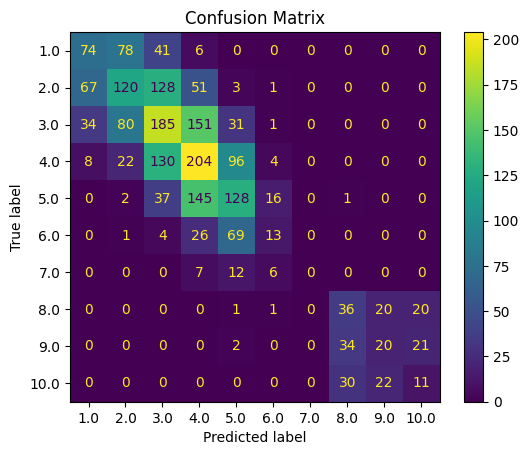

In [ ]:
report(model)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X  = df_num_feats.drop('Anxiety Level (1-10)', axis=1)
y = df_num_feats['Anxiety Level (1-10)']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()


In [ ]:
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
y_pred  = model.predict(X_test_scaled)

In [ ]:
def report(model):
  acc = accuracy_score(y_test, y_pred)
  error = 1-acc
  print(f"Accuracy Score: {acc*100:.2f}%")
  print(f"Error: {error*100:.2f}%")

  conf_mat = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(conf_mat, display_labels=model.classes_)
  disp.plot()
  plt.grid(False)
  disp.ax_.set_title("Confusion Matrix")
  plt.grid(False)

Accuracy Score: 36.05%
Error: 63.95%


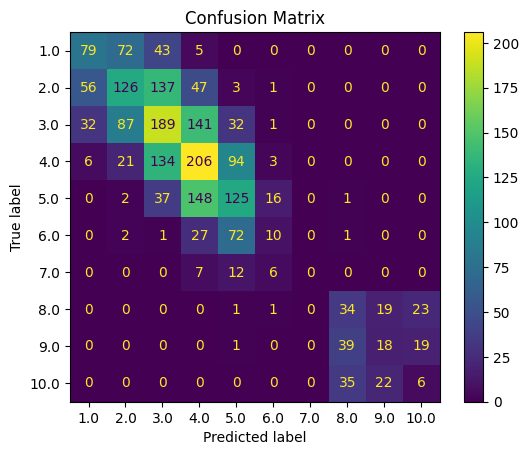

In [ ]:
report(model)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# Statistics

In [ ]:
# Central Values
# Mean, Median AND Mode
np.random.seed(42)

In [ ]:
ages = np.random.randint(low=18, high=40, size=500)

In [ ]:
ages

array([24, 37, 32, 28, 25, 38, 24, 36, 28, 28, 38, 21, 25, 20, 39, 38, 19,
       29, 23, 19, 38, 18, 29, 39, 29, 34, 27, 33, 32, 32, 36, 29, 37, 20,
       22, 36, 24, 38, 26, 24, 35, 21, 31, 35, 26, 38, 19, 37, 32, 24, 29,
       25, 32, 20, 31, 34, 21, 35, 25, 21, 19, 23, 39, 27, 21, 39, 35, 29,
       19, 27, 21, 31, 33, 32, 25, 31, 25, 38, 33, 30, 35, 32, 38, 30, 26,
       32, 30, 18, 24, 26, 18, 29, 25, 28, 36, 34, 25, 20, 20, 18, 22, 27,
       24, 26, 24, 26, 25, 29, 19, 18, 33, 22, 20, 29, 25, 39, 20, 18, 20,
       22, 32, 31, 20, 18, 22, 31, 24, 26, 32, 32, 27, 30, 36, 24, 34, 37,
       21, 22, 24, 30, 32, 28, 21, 30, 24, 36, 39, 19, 27, 30, 38, 23, 29,
       29, 37, 28, 24, 18, 18, 37, 30, 26, 20, 24, 23, 25, 26, 22, 18, 36,
       27, 29, 32, 39, 26, 37, 34, 34, 37, 29, 24, 19, 20, 34, 22, 34, 34,
       34, 19, 19, 39, 22, 18, 18, 36, 19, 38, 29, 23, 21, 28, 34, 23, 22,
       37, 19, 23, 39, 28, 33, 33, 18, 26, 23, 33, 20, 37, 21, 36, 20, 36,
       37, 24, 37, 26, 18

In [ ]:
len(ages)

500

In [ ]:
ages.min()

np.int64(18)

In [ ]:
ages.max()

np.int64(39)

In [ ]:
print(f"Mean: {np.mean(ages):.2f}")

Mean: 28.08


In [ ]:
print(f"Median: {np.median(ages):.2f}")

Median: 28.00


In [ ]:
from scipy import stats

In [ ]:
stats.mode(ages)

ModeResult(mode=np.int64(18), count=np.int64(36))

In [ ]:
income = [10000, 20000, 30000, 40000, 50000, 15000, 25000, 900000]

In [ ]:
# Find Mean, Median and Mode of income dataset
print(f"Mean: {np.mean(income):.2f}")
print(f"Median: {np.median(income):.2f}")
print(f"Mode: {stats.mode(income)}")

Mean: 136250.00
Median: 27500.00
Mode: ModeResult(mode=np.int64(10000), count=np.int64(1))


In [ ]:
np.abs(np.mean(income) - np.median(income))

np.float64(108750.0)

In [ ]:
my_data = np.random.randint(low=40, high=100, size=500)

In [ ]:
print(f"Mean: {np.mean(my_data):.2f}")
print(f"Median: {np.median(my_data):.2f}")
print(f"Mode: {stats.mode(my_data)}")

Mean: 69.84
Median: 69.00
Mode: ModeResult(mode=np.int64(86), count=np.int64(16))


In [ ]:
data_lst = list(my_data)

(array([[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.]]),
 array([4.0000000e+01, 1.8003920e+05, 3.6003840e+05, 5.4003760e+05,
        7.2003680e+05, 9.0003600e+05, 1.0800352e+06, 1.2600344e+06,
        1.4400336e+06, 1.6200328e+06, 1.8000320e+06, 1.9800312e+06,
        2.1600304e+06, 2.3400296e+06, 2.5200288e+06, 2.7000280e+06,
        2.8800272e+06, 3.0600264e+06, 3.2400256e+06, 3.4200248e+06,
        3.6000240e+06, 3.7800232e+06, 3.9600224e+06, 4.1400216e+06,
        4.3200208e+06, 4.5000200e+06, 4.6800192e+06, 4.8600184e+06,
        5.0400176e+06, 5.2200168e+06, 5.4000160e+06, 5.5800152e+06,
        5.7600144e+06, 5.9400136e+06, 6.1200128e+06, 6.3000120e+06,
        6.4800112e+06, 6.6600104e+06, 6.8400096e+06, 7.0200088e+06,
        7.2000080e+06, 7.3800072e+06, 7.5600064e+06, 7.7400056e+06,
   

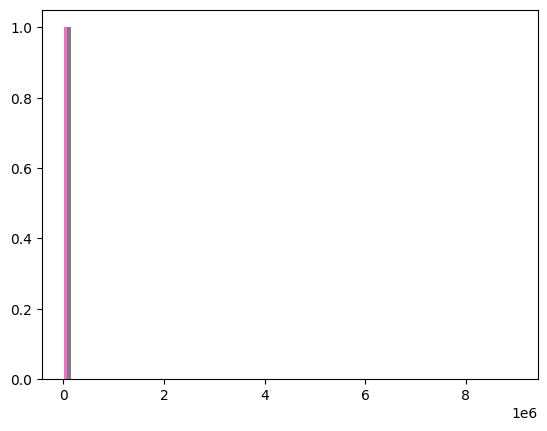

In [ ]:
plt.hist(data_lst, bins=50)

In [ ]:
data_list.append(9000000)

In [ ]:
len(data_lst)

509

In [ ]:
print(f"Mean: {np.mean(data_lst)}")
print(f"Median: {np.median(data_lst)}")
print(f"Mode: {stats.mode(data_lst)}")

In [ ]:
dataset = [11,10,12,14,12,15,14,13,15,102,12,14,17,19,107,10,13,12,14,12,108,12,11,14,13,15,10,15,12,10,14,13,15,10]

In [ ]:
print(f"Mean: {np.mean(dataset)}")
print(f"Median: {np.median(dataset)}")
print(f"Mode: {stats.mode(dataset)}")

Mean: 21.176470588235293
Median: 13.0
Mode: ModeResult(mode=np.int64(12), count=np.int64(7))


(array([31.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.]),
 array([ 10. ,  19.8,  29.6,  39.4,  49.2,  59. ,  68.8,  78.6,  88.4,
         98.2, 108. ]),
 <BarContainer object of 10 artists>)

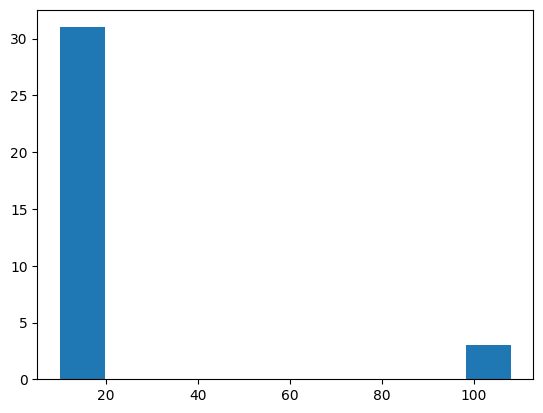

In [ ]:
plt.hist(dataset)

In [ ]:
dataset = [11,10,12,14,12,15,14,13,15,10,12,14,17,19,10,10,13,12,14,12,10,12,11,14,13,15,10,15,12,10,14,13,15,10]

In [ ]:
print(f"Mean: {np.mean(dataset)}")
print(f"Median: {np.median(dataset)}")
print(f"Mode: {stats.mode(dataset)}")

Mean: 12.735294117647058
Median: 12.5
Mode: ModeResult(mode=np.int64(10), count=np.int64(8))


(array([8., 2., 7., 4., 6., 5., 0., 1., 0., 1.]),
 array([10. , 10.9, 11.8, 12.7, 13.6, 14.5, 15.4, 16.3, 17.2, 18.1, 19. ]),
 <BarContainer object of 10 artists>)

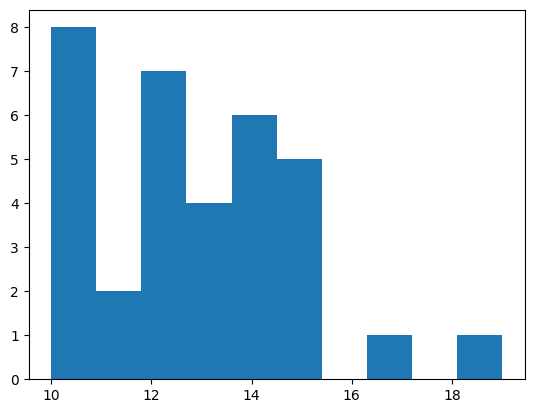

In [ ]:
plt.hist(dataset)

In [ ]:
# central value(27000), std(15000), datapoints(10000)
incomes = np.random.normal(27000, 15000, 10000)

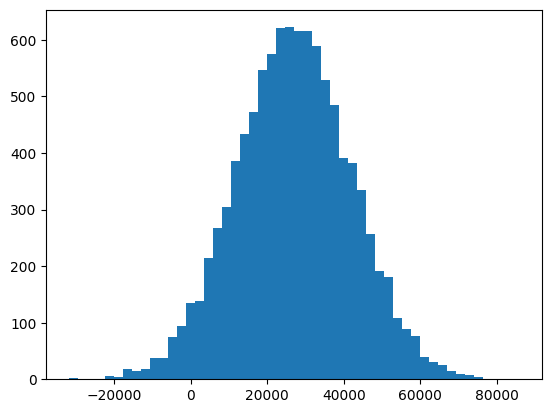

In [ ]:
plt.hist(incomes, bins=50);

In [ ]:
incomes = np.append(incomes, [10000000000, 25000000000, 40000000000])
incomes

array([2.15458168e+04, 2.61458156e+04, 3.16170265e+04, ...,
       1.00000000e+10, 2.50000000e+10, 4.00000000e+10])

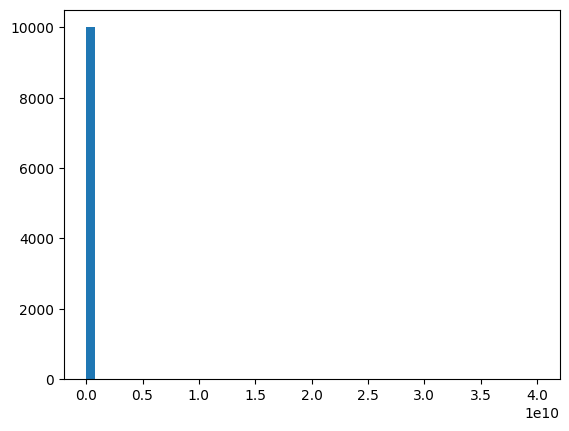

In [ ]:
plt.hist(incomes, bins=50);